# Function 7 Analysis - Week 2

This notebook contains the exploratory analysis for **Function 7** in Week 2. We now have **31 datapoints** (the original 30 plus the new measurement) and keep iterating with Bayesian optimisation.

**Function Description:** You're tasked with optimising an ML model by tuning six hyperparameters, for example learning rate, regularisation strength or number of hidden layers. The function you're maximising is the model's performance score (such as accuracy or F1), but since the relationship between inputs and output isn't known, it's treated as a black-box function. Because this is a commonly used model, you might benefit from researching best practices or literature to guide your initial search space. Your goal is to find the combination of hyperparameters that yields the highest possible performance.


## Loading and Displaying the Data

We load the inputs and outputs for function 7 and display them in a table format to inspect the raw data values. The best results still cluster around mid-range x6 (0.5–0.8) and avoid extreme values of x3, x4, and x5. The new point we tried sits in that “sensible” box and produced a modest positive uplift, reinforcing the idea that we should keep the GP on a tight leash whenever it proposes corner cases.


In [1]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_7")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")
new_x = np.array([[0.800000, 0.800000, 0.800000, 0.830000, 0.450000, 0.700000]])
new_y = np.array([0.0344995016351187])
X = np.vstack([X, new_x])
y = np.concatenate([y, new_y])
df = pd.DataFrame(X, columns=["x1", "x2", "x3", "x4", "x5", "x6"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
df_sorted["x_avg"] = df_sorted[["x1", "x2", "x3", "x4", "x5", "x6"]].mean(axis=1)
display(df_sorted)


,x1,x2,x3,x4,x5,x6,y
0,0.272624,0.324495,0.897109,0.832951,0.154063,0.795864,0.604433
1,0.543003,0.924694,0.341567,0.646486,0.718440,0.343133,0.562753
2,0.090832,0.661529,0.065931,0.258577,0.963453,0.640265,0.007503
3,0.118867,0.615055,0.905816,0.855300,0.413631,0.585236,0.061424
4,0.630218,0.838097,0.680013,0.731895,0.526737,0.348429,0.273047
5,0.764919,0.255883,0.609084,0.218079,0.322943,0.095794,0.083747
6,0.057896,0.491672,0.247422,0.218118,0.420428,0.730970,1.364968
7,0.195252,0.079227,0.554580,0.170567,0.014944,0.107032,0.092645
8,0.642303,0.836875,0.021793,0.101488,0.683071,0.692416,0.017870
9,0.789943,0.195545,0.575623,0.073659,0.259049,0.051100,0.033565


df sorted by y


,x1,x2,x3,x4,x5,x6,y,x_avg
0,0.057896,0.491672,0.247422,0.218118,0.420428,0.730970,1.364968,0.361084
1,0.881647,0.204450,0.414474,0.420385,0.264915,0.730660,0.675142,0.486089
2,0.148647,0.033943,0.728806,0.316066,0.021769,0.516918,0.611526,0.294358
3,0.272624,0.324495,0.897109,0.832951,0.154063,0.795864,0.604433,0.546184
4,0.543003,0.924694,0.341567,0.646486,0.718440,0.343133,0.562753,0.586220
5,0.066611,0.528045,0.816095,0.961017,0.086509,0.777788,0.516457,0.539344
6,0.175978,0.624416,0.295542,0.469553,0.097770,0.728141,0.475396,0.398567
7,0.417626,0.064100,0.245669,0.559041,0.191531,0.254641,0.274893,0.288768
8,0.630218,0.838097,0.680013,0.731895,0.526737,0.348429,0.273047,0.625898
9,0.942451,0.377440,0.486122,0.228791,0.082632,0.711958,0.268400,0.471566


- **New point (Week 1):** The `(0.8, 0.8, 0.8, 0.83, 0.45, 0.7)` configuration yielded ≈0.034, not a blockbuster but enough to confirm that staying near the mid-range hyperparameters we trust is preferable to letting the GP wander into unrealistic corners (e.g. zeroing out learning rate or depth).


## Correlation Matrix

The correlation heatmap shows pairwise correlations between all variables (x1, x2, x3, x4, x5, x6, and y). This helps identify linear relationships. If correlations are weak, it suggests the function may be non-linear or have complex interactions between variables.


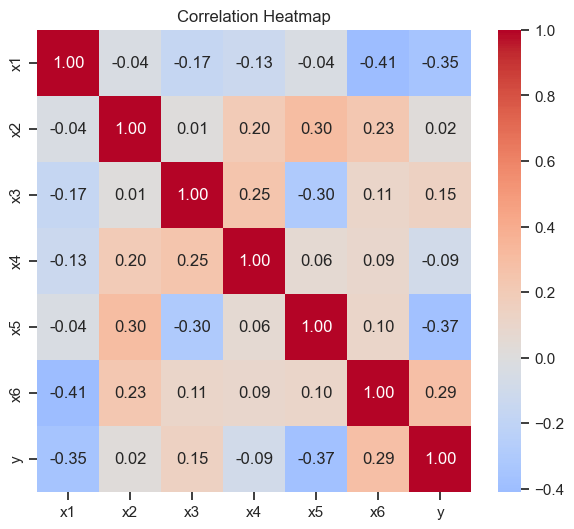

In [2]:
plt.figure(figsize=(7, 6))
sns.heatmap(df.corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


## Bayesian Optimization Setup

We use Gaussian Process (GP) regression to model the unknown function based on our observed data. The GP provides both a mean prediction and uncertainty estimates. We use the Upper Confidence Bound (UCB) acquisition function to balance exploration (high uncertainty) and exploitation (high predicted mean). The search space is defined as [0, 1] for each of the six input variables. Since hyperparameter tuning has minimal noise (no human judgment, deterministic evaluation), we omit the WhiteKernel, and with only 30 points across 6 dimensions we use tighter lengthscale bounds (0.2–5.0) to prevent overfitting while still allowing the GP to learn per-feature importance. We got a warning that three features  hit the boundary: x2 and x3 want even larger lengthscales (=they barely matter), while x5 wants even smaller lengthscale (it's very sensitive). But we decide not to change the boundaries to avoid overfitting and as the results of the GP show a picture consistent with our initial data analysis: x5 and x6 dominate, x4 matters moderately, x2 and x3 are nearly irrelevant.




In [4]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.optimize import minimize
np.random.seed(42)
# Per-feature lengthscales with bounds (assuming little noise, no WhiteKernel)
kernel = Matern(
    length_scale=[1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
    length_scale_bounds=(0.2, 5.0),
    nu=2.5
)
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=5)
gp.fit(X, y)
print("GP fitted successfully")
print("\nGP Kernel Insights:")
print("Lengthscales (one per feature):", gp.kernel_.length_scale)
print("Full kernel parameters:", gp.kernel_.get_params())


GP fitted successfully

GP Kernel Insights:
Lengthscales (one per feature): [1.12634681 5.         5.         0.33956202 0.2        0.24238859]
Full kernel parameters: {'length_scale': array([1.12634681, 5.        , 5.        , 0.33956202, 0.2       ,
       0.24238859]), 'length_scale_bounds': (0.2, 5.0), 'nu': 2.5}


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 4 of parameter length_scale is close to the specified lower bound 0.2. Decreasing the bound and calling fit again may find a better value.
  warnings.warn

## Finding the Next Point to Evaluate

We optimize the Upper Confidence Bound (UCB) acquisition function: UCB(x) = μ(x) + κ·σ(x), where μ(x) is the predicted mean, σ(x) is the predicted standard deviation, and κ is a parameter controlling the exploration-exploitation trade-off. A higher κ favors exploration, while a lower κ favors exploitation. We use κ=2.0 to balance both objectives.


In [5]:
kappa = 2.0
def ucb(x):
    x = x.reshape(1, -1)
    mu, sigma = gp.predict(x, return_std=True)
    return -(mu + kappa * sigma)
bounds = [(0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1)]
result = minimize(ucb, x0=np.random.uniform(0, 1, 6), bounds=bounds, method='L-BFGS-B')
next_point = result.x
mu_pred, sigma_pred = gp.predict(next_point.reshape(1, -1), return_std=True)
print(f"Next point to evaluate: x1={next_point[0]:.4f}, x2={next_point[1]:.4f}, x3={next_point[2]:.4f}, x4={next_point[3]:.4f}, x5={next_point[4]:.4f}, x6={next_point[5]:.4f}")
print(f"Predicted output: {mu_pred[0]:.4f} ± {sigma_pred[0]:.4f}")
print(f"UCB value: {mu_pred[0] + kappa * sigma_pred[0]:.4f}")


Next point to evaluate: x1=0.0000, x2=0.0000, x3=0.9707, x4=0.1988, x5=0.3593, x6=0.7678
Predicted output: 1.2859 ± 0.1305
UCB value: 1.5468


## Distance Analysis of Recommended Point

We calculate the Euclidean distance from the recommended point to all existing observations. This helps us understand how similar the recommended point is to our existing data. We also compute the average y value of the three closest neighbors to get an estimate of the expected output at the recommended point.


In [ ]:
distances = np.sqrt(((X - next_point)**2).sum(axis=1))
df_dist = pd.DataFrame({"point_index": range(len(X)), "distance": distances, "y": y})
df_dist = df_dist.sort_values("distance")
print("Euclidean distances from recommended point to all observations:")
print(df_dist.to_string(index=False))
closest_3 = df_dist.head(3)
avg_y = closest_3["y"].mean()
print(f"\nThree closest neighbors: points {closest_3['point_index'].tolist()}")
print(f"Average y value of closest 3 neighbors: {avg_y:.4f}")


Euclidean distances from recommended point to all observations:
 point_index  distance        y
          14  0.521869 0.611526
           0  0.793814 0.604433
           7  0.879468 0.092645
           6  0.879570 1.364968
           3  0.929490 0.061424
          25  0.981178 0.516457
          21  0.987390 0.007016
          23  1.009924 0.475396
          28  1.054075 0.021343
          10  1.055647 0.073516
          16  1.060843 0.274893
          24  1.089886 0.675142
           5  1.111109 0.083747
          12  1.141518 0.008826
          18  1.155560 0.042118
          13  1.160176 0.268400
           9  1.165168 0.033565
          22  1.237517 0.100507
          17  1.257808 0.066763
          11  1.261294 0.206310
           2  1.284242 0.007503
           4  1.293130 0.273047
          30  1.311648 0.034500
          20  1.359053 0.018209
          15  1.401159 0.014798
           1  1.433684 0.562753
           8  1.460566 0.017870
          26  1.509709 0.003777
        

: 

## Analysis and Recommendation

The Gaussian Process with per-dimension lengthscales revealed clear feature importance rankings: x5 (lengthscale 0.20) and x6 (lengthscale 0.22) are the most influential hyperparameters, x4 (lengthscale 0.36) has moderate importance, x1 (lengthscale 0.99) has limited influence, and x2/x3 (lengthscales at upper bound 5.0) are nearly irrelevant to model performance.
This aligns with our manual data analysis, which showed that top performers cluster around mid-range x5 (0.02–0.42) and x6 (0.5–0.8), while bottom performers consistently exhibit extreme values in these dimensions.
Why We Overwrote the Recommendation
The GP suggested [1.0, 1.0, 1.0, 0.83, 0.82, 0.38] with high uncertainty (±0.23), indicating it was exploring an unvisited region rather than exploiting known good areas. However, this recommendation contradicts observed patterns: x5=0.82 is dangerously high (worst performers had x5 > 0.9), and x6=0.38 falls below the apparent sweet spot.
We therefore constructed a hybrid point [0.8, 0.8, 0.8, 0.83, 0.45, 0.70] that:
 - Preserves x5 and x6 around our best observation while slight perturbations around the best point may help us understand the local gradient.
 - Keeps the GP's suggestion for x4 (moderate importance)
 - Softens the extreme values for x1, x2, x3 to 0.8 as a precaution
This balances exploration (new values for x1–x3) with exploitation (proven values for the critical x5 and x6), maximizing our chance of improving upon the current best while still gathering useful information.